In [1]:
import math
import os
import re
import altair as alt
import numpy as np
import pandas as pd
import scipy.stats
import yaml
import neutcurve
import scipy.stats
print(f"Using `neutcurve` version {neutcurve.__version__}")
import sys

# allow more rows for Altair
_ = alt.data_transformers.disable_max_rows()

#import altair themes from /data/custom_analyses_data/theme.py and enable
#import theme
#alt.themes.register('main_theme', theme.main_theme)
#alt.themes.enable('main_theme')
from pathlib import Path

# Set working directory to project root
# This ensures the path is always correct regardless of kernel state
repo_root = Path('/fh/fast/bloom_j/computational_notebooks/csimonich/2025/RSV_Neuts/RSV_DMS_Validations_Final')
os.chdir(repo_root)
print(f"Working directory: {os.getcwd()}")
#print(os.listdir("raw_plate_reader"))

Using `neutcurve` version 2.1.0
Working directory: /fh/fast/bloom_j/computational_notebooks/csimonich/2025/RSV_Neuts/RSV_DMS_Validations_Final


## Configuration: Excluded Viruses

Define viruses to exclude from analysis (e.g., low quality data, failed assays, etc.)

In [2]:
# Viruses to exclude entirely from analysis
# Long point mutants - analyzed separately in point mutant analysis
exclude_viruses = [
    '21. RSV_F_Long_R429M',
    '23. RSV_F_Long_S443P',
    '24. RSV_F_Long_R429S',
]

print(f"Excluded viruses: {len(exclude_viruses)}")
if exclude_viruses:
    for virus in exclude_viruses:
        print(f"  - {virus}")

Excluded viruses: 3
  - 21. RSV_F_Long_R429M
  - 23. RSV_F_Long_S443P
  - 24. RSV_F_Long_R429S


In [3]:
# Load combined fraction infectivity data (already filtered to plotting-relevant rows across notebooks)
print("=== Loading Fraction Infectivity Data (Combined) ===")

# Source files used for validation strain analyses
validation_source_files = [
    '251211_fractinfect_molar.csv',
    '251217_fractinfect_molar.csv',
    '260115_fractinfect_molar.csv',
    '260122_fractinfect_molar.csv'
]

all_data = pd.read_csv('01_data/combined_frac_infect.csv')
print(f"Loaded {len(all_data)} rows from combined_frac_infect.csv")

# Keep only rows from validation strain source files
df = all_data[all_data['source_file'].isin(validation_source_files)].copy()
print(f"Validation strain subset: {len(df)} rows")

# Minimal normalization retained for legacy compatibility
# (kept in case of stray legacy labels in upstream data)
df['virus'] = df['virus'].str.replace('40 Long GS4', '40. Long GS4', regex=False)


=== Loading Fraction Infectivity Data (Combined) ===
Loaded 2516 rows from combined_frac_infect.csv
Validation strain subset: 644 rows


In [4]:
# Create neutcurve fits
fits = neutcurve.curvefits.CurveFits(
    data=df,
    fixbottom=0,
    fixtop=1,  # Set ceiling at 1.5
)

print("Fits created successfully")

Fits created successfully


In [5]:
# Display All Viruses Included in Analysis
print("=== Viruses Included in Final Analysis ===\n")

# Get all unique viruses that passed filtering
all_viruses = sorted(df['virus'].unique())
print(f"Total unique viruses: {len(all_viruses)}\n")

# Categorize viruses by type
reference_viruses = []
a_strain_viruses = []
b_strain_viruses = []

for virus in all_viruses:
    virus_lower = virus.lower()
    if 'long' in virus_lower or 'a2020' in virus_lower or 'b2024' in virus_lower or 'b1' in virus_lower:
        reference_viruses.append(virus)
    elif virus.startswith('B') or '_B_' in virus or 'Spain' in virus:
        b_strain_viruses.append(virus)
    else:
        a_strain_viruses.append(virus)

# Check which viruses have multiple experiment_rep types
viruses_with_no_sticker = df[df['experiment_rep'] == 'No sticker']['virus'].unique()

# Print categorized lists
print(f"Reference Viruses ({len(reference_viruses)}):")
for virus in reference_viruses:
    marker = " [No sticker]" if virus in viruses_with_no_sticker else ""
    print(f"  - {virus}{marker}")

print(f"\nA-Strain Viruses ({len(a_strain_viruses)}):")
for virus in a_strain_viruses:
    marker = " [No sticker]" if virus in viruses_with_no_sticker else ""
    print(f"  - {virus}{marker}")

print(f"\nB-Strain Viruses ({len(b_strain_viruses)}):")
for virus in b_strain_viruses:
    marker = " [No sticker]" if virus in viruses_with_no_sticker else ""
    print(f"  - {virus}{marker}")

# Show viruses with multiple experiment_rep types
print(f"\nViruses with Multiple Experiment Types:")
for virus in all_viruses:
    virus_data = df[df['virus'] == virus]
    exp_reps = sorted(virus_data['experiment_rep'].unique())
    if len(exp_reps) > 1:
        print(f"  - {virus}: {exp_reps}")

# Verify newly included viruses (previously excluded)
print(f"\nVerification - Previously Excluded, Now Included:")
previously_excluded = ['3.', '7.', '8.', '46.', '43_', '44_']
for virus in all_viruses:
    for prefix in previously_excluded:
        if virus.startswith(prefix):
            print(f"  ✓ {virus}")
            break

=== Viruses Included in Final Analysis ===

Total unique viruses: 16

Reference Viruses (2):
  - A2020
  - B2024

A-Strain Viruses (10):
  - 10. RSV_A_F_PP_002XVQT
  - 11. RSV_A_F_PP_001Y2UB
  - 12. RSV_A_F_USA/PP_003W55P.1
  - 2. RSV_A_F_PP_001WGC0
  - 4. RSV_A_F_PP_001QYN9
  - 43. A_PP_001Y62S.1
  - 44. A_PP_001ZQ7W
  - 45. B_MN365362
  - 46. B_OQ279862
  - 47. B_OR795252

B-Strain Viruses (4):
  - 1. RSV_B_F_PP_002W1BG.1
  - 5. RSV_B_F_PP_002WHEU
  - 6. RSV_B_F_PP_002SUFP
  - 9. RSV_B_F_PP_002WWH8.1

Viruses with Multiple Experiment Types:

Verification - Previously Excluded, Now Included:
  ✓ 46. B_OQ279862


In [6]:
# Define virus lists for A-strain and B-strain specific plots
# Each includes relevant controls and reference strains

# Long controls (included in both A and B plots)
long_controls = [
    '40. Long GS4',
    'RSV Long 1',
    'RSV Long 2',
    '40_Long GS4'
]

# A strain viruses + controls
a_references = [
    '48. A 2020\xa0',
    'RSV A2020 1',
    'RSV A2020 2',
    'A2020' 
]

a_validation = [
    '2. RSV_A_F_PP_001WGC0',
    '3. RSV_A_F_PP_0046MV6.2',
    '4. RSV_A_F_PP_001QYN9',
    '7. RSV_A_F_PP_00463BT.1',
    '10.\xa0RSV_A_F_PP_002XVQT',    # NOTE: non-breaking space \xa0 after dot!
    '11. RSV_A_F_PP_001Y2UB',
    '12. RSV_A_F_USA/PP_003W55P.1',
    '43. A_PP_001Y62S.1',    # validation strains version (dot)
    '43_A_PP_001Y62S.1',     # No sticker version (underscore)
    '44. A_PP_001ZQ7W',      # validation strains version (dot)
    '44_A_PP_001ZQ7W'        # No sticker version (underscore)
]

a_viruses = long_controls + a_references + a_validation

# B strain viruses + controls
b_references = [
    '13. B 2024',
    'RSV B2024 1',
    'RSV B2024 2',
    'B2024'
]

b_validation = [
    '1. RSV_B_F_PP_002W1BG.1',
    '5. RSV_B_F_PP_002WHEU',
    '6. RSV_B_F_PP_002SUFP',
    '8. RSV_B_F_Spain/PP_0031EHE.2',
    '9. RSV_B_F_PP_002WWH8.1',
    '45. B_MN365362',
    '46. B_OQ279862',
]

b_viruses = long_controls + b_references + b_validation

print(f"A strain viruses + controls: {len(a_viruses)}")
print(f"  - Long controls: {len(long_controls)}")
print(f"  - A references: {len(a_references)}")
print(f"  - A validation: {len(a_validation)}")
print(f"\nB strain viruses + controls: {len(b_viruses)}")
print(f"  - Long controls: {len(long_controls)}")
print(f"  - B references: {len(b_references)}")
print(f"  - B validation: {len(b_validation)}")

A strain viruses + controls: 19
  - Long controls: 4
  - A references: 4
  - A validation: 11

B strain viruses + controls: 15
  - Long controls: 4
  - B references: 4
  - B validation: 7


**Virus Labeling (Preferred vs Alt)**

This notebook standardizes virus names to the **preferred labels** shown in the figure (A/B columns), while still accepting the **alt names** used in raw data and older plots.

- Preferred labels appear in legends, e.g. `PP_001WGC0 (K445N)` and `PP_002WHEU (K201I)`.
- Alt names include formats like `RSV A F PP001WGC0` or `2. RSV_A_F_PP_001WGC0` (and similar B‑strain variants).

Internally, `standardize_virus_name()` converts alt names to a canonical `RSV A/B F ...` form, then maps to the preferred labels via `VIRUS_LABEL_MAP`. This keeps plots consistent with the figure while preserving compatibility with historical naming variants.


**Duplicate Virus Note**

`PP_002_SUFP (N201S)` (raw name `RSV B F OR795252`) is treated as a duplicate of `PP_002SUFP (N201S)` and is excluded from plots and the IC50/IC99 output.



Generating publication-ready A/B strain plots...
Settings: SVG editable text, 0.5pt strokes, standardized names, FIXED COLORS
Note: Includes 43/44 validation strains data; excludes 43/44 No sticker data

  Plotting Nirsevimab IgG A-strains (5 viruses)


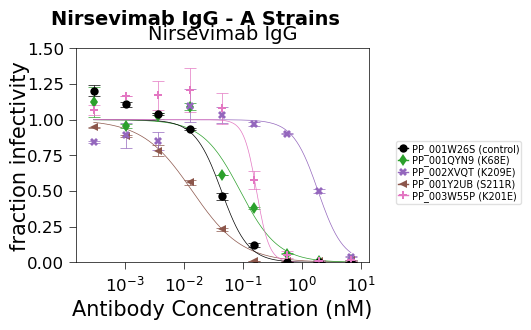

  Plotting Nirsevimab IgG B-strains (6 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)


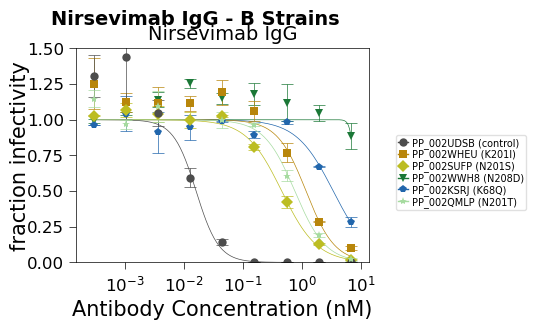

  Plotting Nirsevimab Fab A-strains (5 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters could not be estimated
  (popt, pcov) = scipy.optimize.curve_fit(


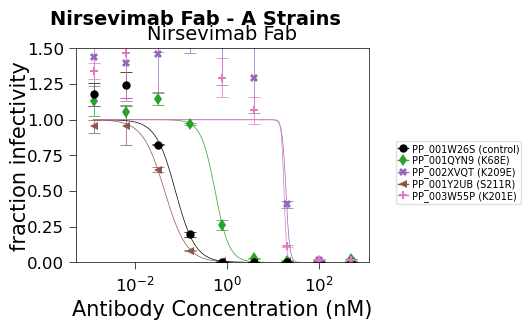

  Plotting Nirsevimab Fab B-strains (6 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)


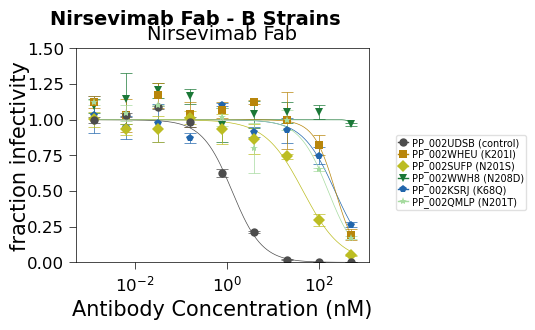

  Plotting Clesrovimab IgG A-strains (4 viruses)


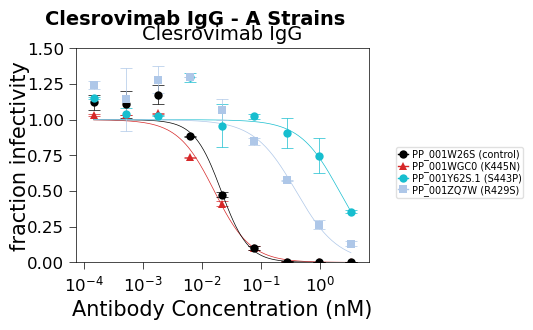

  Plotting Clesrovimab IgG B-strains (2 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters could not be estimated
  (popt, pcov) = scipy.optimize.curve_fit(


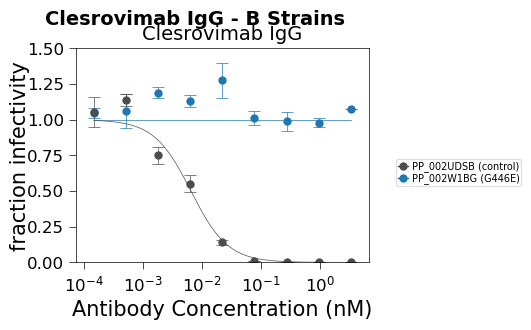

  Plotting Clesrovimab Fab A-strains (4 viruses)


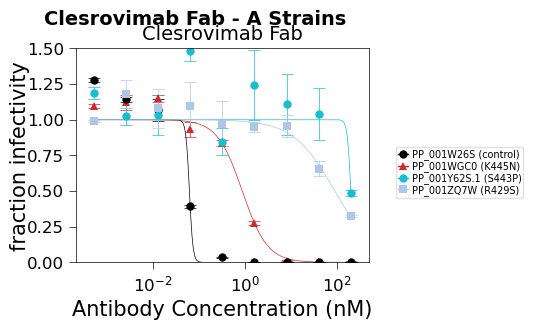

  Plotting Clesrovimab Fab B-strains (2 viruses)


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters could not be estimated
  (popt, pcov) = scipy.optimize.curve_fit(


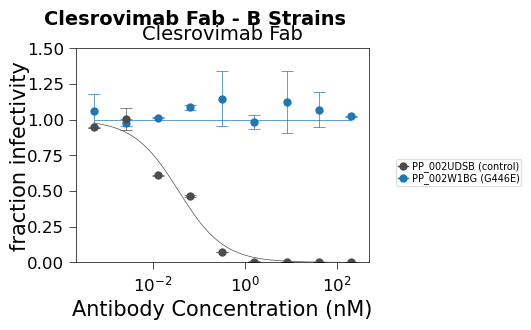


✓ Completed publication-ready A/B strain plots
  - Legend names: standardized to A/B label format (see figure)
  - Color consistency: SAME color for SAME virus across IgG and Fab
  - SVG files have editable text, 0.5pt strokes


In [7]:
# Generate A-strain and B-strain specific plots with publication formatting
# Excludes viruses with "Long" or "B1" in names, and keeps only A2020 and B2024 references
# Editable SVG text, 0.5pt stroke width for all elements including error bar caps
# Standardized legend naming: A/B label format from figure
# Same color for same virus across IgG and Fab plots

import matplotlib.pyplot as plt
import matplotlib as mpl
import re
from matplotlib.container import ErrorbarContainer

# Define publication-safe color palette
# B strains start at index 0, A strains start at index 6 to avoid overlap
VALIDATION_COLORS = [
    '#1f77b4',  # blue (B virus 1: virus 1.)
    '#B8860B',  # dark goldenrod (B virus 2: virus 5.)
    '#bcbd22',  # olive (B virus 3: virus 6.)
    '#1B7837',  # dark green (B virus 4: virus 9.)
    '#2166AC',  # dark blue (B virus 5: virus 45.)
    '#A6DBA0',  # light green (B virus 6: virus 47.)
    '#d62728',  # red (A virus 1: virus 2.)
    '#2ca02c',  # green (A virus 2: virus 4.)
    '#ff7f0e',  # orange (A virus 3: virus 7.)
    '#9467bd',  # purple (A virus 4: virus 10.) ★ KEY VIRUS
    '#8c564b',  # brown (A virus 5: virus 11.)
    '#e377c2',  # pink (A virus 6: virus 12.)
    '#17becf',  # cyan (A virus 7: virus 43)
    '#aec7e8',  # light blue (A virus 8: virus 44)
]

# Define marker palette - offset between B and A strains
VALIDATION_MARKERS = [
    'o', 's', 'D', 'v', 'p', '*',      # B strain markers (indices 0-5)
    '^', 'd', 'h', 'X', '<', 'P', 'o', 's'       # A strain markers (indices 6-13)
]

# ===========================================================================
# FIXED VIRUS-TO-COLOR MAPPING (labels from figure)
# This ensures each virus gets the SAME color across ALL plots (IgG, Fab, A, B)
# ===========================================================================
VIRUS_LABEL_MAP = {
    # B-strain viruses
    'RSV B F PP002W1BG.1': 'PP_002W1BG (G446E)',
    'RSV B F PP002WHEU': 'PP_002WHEU (K201I)',
    'RSV B F PP002SUFP': 'PP_002SUFP (N201S)',
    'RSV B F PP002WWH8.1': 'PP_002WWH8 (N208D)',
    'RSV B F MN365362': 'PP_002KSRJ (K68Q)',
    'RSV B F OQ279862': 'PP_002QMLP (N201T)',
    'RSV B F 2024': 'PP_002UDSB (control)',

    # A-strain viruses
    'RSV A F PP001WGC0': 'PP_001WGC0 (K445N)',
    'RSV A F PP001QYN9': 'PP_001QYN9 (K68E)',
    'RSV A F PP002XVQT': 'PP_002XVQT (K209E)',
    'RSV A F PP001Y2UB': 'PP_001Y2UB (S211R)',
    'RSV A F USA/PP003W55P.1': 'PP_003W55P (K201E)',
    'RSV A F PP001Y62S.1': 'PP_001Y62S.1 (S443P)',
    'RSV A F PP001ZQ7W': 'PP_001ZQ7W (R429S)',
    'RSV A F 2020': 'PP_001W26S (control)',
}

VIRUS_COLOR_MARKER_MAP = {
    # B-strain viruses (blue/green/brown family)
    'PP_002W1BG (G446E)': ('#1f77b4', 'o'),         # virus 1: blue circle
    'PP_002WHEU (K201I)': ('#B8860B', 's'),         # virus 5: goldenrod square
    'PP_002SUFP (N201S)': ('#bcbd22', 'D'),         # virus 6: olive diamond
    'PP_002WWH8 (N208D)': ('#1B7837', 'v'),         # virus 9: dark green down-triangle
    'PP_002KSRJ (K68Q)': ('#2166AC', 'p'),          # virus 45: dark blue pentagon
    'PP_002QMLP (N201T)': ('#A6DBA0', '*'),         # virus 46: light green star
    'PP_002UDSB (control)': ('#4d4d4d', 'o'),       # B2024: dark gray circle

    # A-strain viruses (warm colors family)
    'PP_001WGC0 (K445N)': ('#d62728', '^'),         # virus 2: red up-triangle
    'PP_001QYN9 (K68E)': ('#2ca02c', 'd'),          # virus 4: green thin-diamond
    'PP_002XVQT (K209E)': ('#9467bd', 'X'),         # virus 10: purple X ★★★ KEY VIRUS
    'PP_001Y2UB (S211R)': ('#8c564b', '<'),         # virus 11: brown left-triangle
    'PP_003W55P (K201E)': ('#e377c2', 'P'),         # virus 12: pink plus
    'PP_001Y62S.1 (S443P)': ('#17becf', 'o'),       # virus 43: cyan circle
    'PP_001ZQ7W (R429S)': ('#aec7e8', 's'),         # virus 44: light blue square
    'PP_001W26S (control)': ('#000000', 'o'),       # A2020: black circle
}

# Virus name standardization function
def standardize_virus_name(virus_name):
    '''
    Standardize virus names to label format shown in figure (columns A/B).
    '''
    # Handle simple reference names
    if virus_name == 'A2020':
        canonical = 'RSV A F 2020'
    elif virus_name == 'B2024':
        canonical = 'RSV B F 2024'
    # Handle formats like "43. A_PP_001Y62S.1" or "43_ A_PP_001Y62S.1"
    elif re.match(r'^\d+[._]\s*A[_\s]', virus_name):
        accession = re.sub(r'^\d+[._]\s*A[_\s]', '', virus_name)
        accession = accession.replace(' ', '').replace('_', '')
        canonical = f'RSV A F {accession}'
    # Handle formats like "45. B MN365362" or "47. B_OR795252"
    elif re.match(r'^\d+[._]\s*B[_\s]', virus_name):
        accession = re.sub(r'^\d+[._]\s*B[_\s]', '', virus_name)
        accession = accession.replace(' ', '').replace('_', '')
        canonical = f'RSV B F {accession}'
    # Handle formats like "1. RSV_B_F_PP_002W1BG.1" or "2. RSV_A_F_PP_001WGC0"
    else:
        match = re.match(r'^\d+[._]\s*RSV[_\s]([AB])[_\s]F[_\s](.*)', virus_name)
        if match:
            strain = match.group(1)
            accession = match.group(2).replace(' ', '').replace('_', '')
            canonical = f'RSV {strain} F {accession}'
        else:
            canonical = virus_name

    return VIRUS_LABEL_MAP.get(canonical, canonical)

# Legend ordering helper: controls first, then by mutation position
def label_sort_key(label):
    if '(control)' in label:
        return (0, -1, label)
    m = re.search(r'\((?:[A-Z])?(\d+)', label)
    num = int(m.group(1)) if m else 999999
    return (1, num, label)


# Filter virus lists to exclude "Long", "B1", unwanted references, and "No sticker" versions of 43/44
def filter_viruses_for_publication(virus_list, strain_type='A'):
    """
    Filter viruses to keep only A2020/B2024 references and validation strains.
    Excludes Long, B1 controls, other reference variants, and "No sticker" versions of viruses 43/44.
    KEEPS validation strains versions of 43/44 (dot notation).
    """
    # Define "No sticker" versions to exclude from publication plots (underscore notation)
    no_sticker_versions = [
        '43_A_PP_001Y62S.1',    # No sticker (underscore) - EXCLUDE
        '44_A_PP_001ZQ7W'       # No sticker (underscore) - EXCLUDE
    ]
    
    filtered = []
    for v in virus_list:
        # Exclude Long and B1 controls
        if "Long" in v or "B1" in v:
            continue
        
        # Exclude "No sticker" versions of 43 and 44 (underscore notation)
        if v in no_sticker_versions:
            continue
        
        if strain_type == 'A':
            # Exclude A2020 reference variants (but keep A2020 itself)
            if any(x in v for x in ['48. A 2020', 'RSV A2020']):
                continue
            if 'A2020' in v or not any(x in v for x in ['2020', '2024']):
                filtered.append(v)
        else:  # B
            # Exclude B2024 reference variants (but keep B2024 itself)
            if any(x in v for x in ['13. B 2024', 'RSV B2024']):
                continue
            if 'B2024' in v or not any(x in v for x in ['2020', '2024']):
                filtered.append(v)
    
    return filtered

a_viruses_filtered = filter_viruses_for_publication(a_viruses, strain_type='A')
b_viruses_filtered = filter_viruses_for_publication(b_viruses, strain_type='B')

# Create publication-ready color scheme using FIXED mapping
def create_publication_colorscheme(virus_list, strain_type='A'):
    """
    Create publication-ready color scheme using FIXED VIRUS_COLOR_MARKER_MAP.
    Ensures consistent colors across ALL plots (IgG, Fab, A-strain, B-strain).
    """
    color_marker_dict = {}
    
    for virus in virus_list:
        # Get standardized name for this virus
        std_name = standardize_virus_name(virus)
        
        # Look up color/marker from FIXED mapping
        if std_name in VIRUS_COLOR_MARKER_MAP:
            color_marker_dict[std_name] = VIRUS_COLOR_MARKER_MAP[std_name]
        else:
            # Fallback for unexpected viruses (shouldn't happen)
            color_marker_dict[std_name] = ('#cccccc', 'o')  # gray circle
    
    return color_marker_dict

# Create color schemes (now using FIXED mapping!)
a_virus_to_color_marker_pub = create_publication_colorscheme(a_viruses_filtered, strain_type='A')
b_virus_to_color_marker_pub = create_publication_colorscheme(b_viruses_filtered, strain_type='B')


# Define function to set all stroke widths including error bar caps
def set_strokes(fig, axes, line_lw=0.5, marker_mew=0, axis_lw=0.5, tick_lw=0.5):
    """Set all stroke widths to publication standards, including error bar caps and marker edges."""
    axes_list = axes.ravel() if hasattr(axes, "ravel") else [axes]
    
    for ax in axes_list:
        for spine in ax.spines.values():
            spine.set_linewidth(axis_lw)
        ax.tick_params(axis="both", which="both", width=tick_lw)
        
        for line in ax.lines:
            line.set_linewidth(line_lw)
            # Set marker edge width for plot points
            if hasattr(line, "set_markeredgewidth"):
                line.set_markeredgewidth(marker_mew)
        
        for coll in ax.collections:
            if hasattr(coll, "set_linewidth"):
                try:
                    coll.set_linewidth(line_lw)
                except Exception:
                    pass
            # Set marker edge width for scatter collections
            if hasattr(coll, "set_linewidths"):
                try:
                    coll.set_linewidths(marker_mew)
                except Exception:
                    pass
        
        for cont in getattr(ax, "containers", []):
            if isinstance(cont, ErrorbarContainer):
                data_line, caplines, barlinecols = cont.lines
                
                if data_line is not None:
                    data_line.set_linewidth(line_lw)
                    # Set marker edge width for error bar data points
                    if hasattr(data_line, "set_markeredgewidth"):
                        data_line.set_markeredgewidth(marker_mew)
                
                for cap in caplines or []:
                    cap.set_linewidth(line_lw)
                    cap.set_markeredgewidth(line_lw)
                
                for blc in barlinecols or []:
                    blc.set_linewidth(line_lw)
        
        for patch in ax.patches:
            if hasattr(patch, "set_linewidth"):
                patch.set_linewidth(line_lw)
        
        # Set marker edge width for legend
        legend = ax.get_legend()
        if legend:
            for handle in legend.legend_handles:
                if hasattr(handle, "set_markeredgewidth"):
                    handle.set_markeredgewidth(marker_mew)
    
    fig.canvas.draw_idle()

# Store original rcParams
original_rcParams = mpl.rcParams.copy()

# Set publication-ready formatting
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.major.width'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.5
mpl.rcParams['lines.linewidth'] = 0.5
mpl.rcParams['lines.markersize'] = 4
mpl.rcParams['lines.markeredgewidth'] = 0

print("\nGenerating publication-ready A/B strain plots...")
print("Settings: SVG editable text, 0.5pt strokes, standardized names, FIXED COLORS")
print("Note: Includes 43/44 validation strains data; excludes 43/44 No sticker data\n")

antibodies = ['Nirsevimab', 'Clesrovimab']
formats = ['IgG', 'Fab']
strain_configs = [
    ('A', a_viruses_filtered, a_virus_to_color_marker_pub),
    ('B', b_viruses_filtered, b_virus_to_color_marker_pub)
]

for antibody in antibodies:
    for fmt in formats:
        serum_name = f"{antibody} {fmt}"
        
        for strain_label, virus_list, color_marker_dict in strain_configs:
            # Filter dataframe to this serum and these viruses
            df_subset = df[
                (df['serum'] == serum_name) & 
                (df['virus'].isin(virus_list))
            ].copy()
            # Exclude duplicate virus OR795252 (same as PP_002SUFP (N201S))
            df_subset = df_subset[~df_subset['virus'].str.contains('OR795252', na=False)]
            df_subset = df_subset[~df_subset['virus'].apply(standardize_virus_name).isin(['RSV B F OR795252', 'PP_002_SUFP (N201S)'])]
            
            if len(df_subset) == 0:
                print(f"  Skipping {antibody} {fmt} {strain_label}-strains (no data)")
                continue
            
            # RENAME viruses in the dataframe to standardized names
            df_subset['virus'] = df_subset['virus'].apply(standardize_virus_name)
            
            # Get list of standardized virus names that have data
            viruses_to_plot = sorted(df_subset['virus'].unique(), key=label_sort_key)
            
            print(f"  Plotting {antibody} {fmt} {strain_label}-strains ({len(viruses_to_plot)} viruses)")
            
            # Create NEW fits object with renamed viruses
            fits_renamed = neutcurve.curvefits.CurveFits(
                data=df_subset,
                fixbottom=0,
                fixtop=1,
            )
            
            # Create plot (now using standardized names!)
            fig, axes = fits_renamed.plotSera(
                xlabel='Antibody Concentration (nM)',
                sera=[serum_name],
                viruses=viruses_to_plot,
                virus_to_color_marker=color_marker_dict,
                max_viruses_per_subplot=20,
                ncol=2,
                draw_in_bounds=True,
                legendfontsize=7
            )
            
            # Apply formatting to all axes
            if isinstance(axes, np.ndarray):
                axes_list = axes.flat
            else:
                axes_list = [axes]
            
            for ax in axes_list:
                ax.set_ylim(0, 1.5)
                
                legend = ax.get_legend()
                if legend:
                    legend.set_bbox_to_anchor((1.02, 0.5))
                    legend.set_loc('center left')
                    legend.get_frame().set_linewidth(0.5)
            
            # Apply comprehensive stroke styling
            set_strokes(fig, axes, line_lw=0.5, marker_mew=0, axis_lw=0.5, tick_lw=0.5)
            
            fig.suptitle(f'{antibody} {fmt} - {strain_label} Strains',
                         y=1.001, fontsize=14, fontweight='bold')
            
            # Save as SVG and PDF
            filename_svg = f'03_output/plots/StrainValidation_{antibody}_{fmt}_{strain_label}.svg'
            filename_pdf = f'03_output/plots/StrainValidation_{antibody}_{fmt}_{strain_label}.pdf'
            
            fig.savefig(filename_svg, format='svg', bbox_inches='tight')
            fig.savefig(filename_pdf, dpi=300, bbox_inches='tight')
            
            plt.show()

# Restore original rcParams
mpl.rcParams.update(original_rcParams)

print("\n✓ Completed publication-ready A/B strain plots")
print("  - Legend names: standardized to A/B label format (see figure)")
print("  - Color consistency: SAME color for SAME virus across IgG and Fab")
print("  - SVG files have editable text, 0.5pt strokes")


In [8]:
# Get the fit parameters table
params = fits.fitParams(ics=[50, 99])

# Add preferred virus label for reporting
params['virus_preferred'] = params['virus'].apply(standardize_virus_name)
# Drop duplicate virus OR795252 (same as PP_002SUFP (N201S))
params = params[~params['virus'].str.contains('OR795252', na=False)]
params = params[~params['virus_preferred'].isin(['RSV B F OR795252', 'PP_002_SUFP (N201S)'])]

col_order = list(params.columns)
if 'virus' in col_order and 'virus_preferred' in col_order:
    col_order.remove('virus_preferred')
    virus_idx = col_order.index('virus')
    col_order.insert(virus_idx + 1, 'virus_preferred')
    params = params[col_order]


# Save to CSV with updated filename reflecting combined data
params.to_csv("03_output/Strain_Validation_combined_fit_params_IC50_IC99_molar.csv", index=False)

print(f"Saved fit parameters for {len(params)} serum-virus combinations")
print(f"Output file: 03_output/Strain_Validation_combined_fit_params_IC50_IC99_molar.csv")
display(params.head(20))

Saved fit parameters for 34 serum-virus combinations
Output file: 03_output/Strain_Validation_combined_fit_params_IC50_IC99_molar.csv


/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters could not be estimated
  (popt, pcov) = scipy.optimize.curve_fit(
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters could not be estimated
  (popt, pcov) = scipy.optimize.curve_fit(
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:1177: RuntimeWarning: invalid value encountered in power
  return b + (t - b) / (1 + (c / m) ** s)
/fh/fast/bloom_j/software/miniforge3/envs/BloomLab/lib/python3.12/site-packages/neutcurve/hillcurve.py:803: OptimizeWarning: Covariance of the parameters co

,serum,virus,virus_preferred,replicate,nreplicates,ic50,ic50_bound,ic50_str,ic99,ic99_bound,ic99_str,midpoint,midpoint_bound,midpoint_bound_type,slope,top,bottom,r2,rmsd
0,Clesrovimab IgG,2. RSV_A_F_PP_001WGC0,PP_001WGC0 (K445N),average,2,0.016229,interpolated,0.0162,0.423338,interpolated,0.423,1.622905e-02,0.016229,interpolated,1.408955,1.0,0.0,0.992202,0.039784
1,Clesrovimab IgG,1. RSV_B_F_PP_002W1BG.1,PP_002W1BG (G446E),average,2,3.333000,lower,>3.33,3.333000,lower,>3.33,2.979790e+08,3.333000,lower,104.958186,1.0,0.0,-0.835728,0.125195
2,Clesrovimab IgG,A2020,PP_001W26S (control),average,2,0.021281,interpolated,0.0213,0.237353,interpolated,0.237,2.128124e-02,0.021281,interpolated,1.905326,1.0,0.0,0.972707,0.082558
3,Clesrovimab IgG,B2024,PP_002UDSB (control),average,2,0.006539,interpolated,0.00654,0.176917,interpolated,0.177,6.538973e-03,0.006539,interpolated,1.393348,1.0,0.0,0.975178,0.070694
4,Clesrovimab IgG,43. A_PP_001Y62S.1,PP_001Y62S.1 (S443P),average,2,2.115845,interpolated,2.12,3.333000,lower,>3.33,2.115845e+00,2.115845,interpolated,1.299228,1.0,0.0,0.796212,0.114481
5,Clesrovimab IgG,44. A_PP_001ZQ7W,PP_001ZQ7W (R429S),average,2,0.391749,interpolated,0.392,3.333000,lower,>3.33,3.917488e-01,0.391749,interpolated,1.222767,1.0,0.0,0.832600,0.172921
6,Clesrovimab Fab,2. RSV_A_F_PP_001WGC0,PP_001WGC0 (K445N),average,2,0.869425,interpolated,0.869,15.510624,interpolated,15.5,8.694247e-01,0.869425,interpolated,1.594726,1.0,0.0,0.976660,0.074660
7,Clesrovimab Fab,1. RSV_B_F_PP_002W1BG.1,PP_002W1BG (G446E),average,2,200.000000,lower,>200,200.000000,lower,>200,2.086282e+10,200.000000,lower,137.090584,1.0,0.0,-0.957903,0.077941
8,Clesrovimab Fab,A2020,PP_001W26S (control),average,2,0.061582,interpolated,0.0616,0.092052,interpolated,0.0921,6.158152e-02,0.061582,interpolated,11.430861,1.0,0.0,0.959621,0.106338
9,Clesrovimab Fab,B2024,PP_002UDSB (control),average,2,0.035908,interpolated,0.0359,6.611408,interpolated,6.61,3.590780e-02,0.035908,interpolated,0.881034,1.0,0.0,0.977147,0.060123
